In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 74.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=be4ed2d7d2eba475743da6673eb919ba69abdad5b7bbbc992cd81e6e497aa5bf
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Three qubit phase-flip error-correcting code

# In a similar way to the bit-flip error-correcting code, implement the phase-flip error-correcting code.
# Check that the code can correct a single phase flip but not two or more simultaneous phase flips.
# What happens if you introduce a bit flip?
# The next cell still has the simulation and measurement. Implement the phase flip code on the same qubits
# as for the bit flip code, so you can reuse the simulation and measurement.



In [3]:
### Simple implementation
# Prepare qubit 0 in a superposition
# Encode qubit 0 across qubits 0, 1, and 2
# Apply H gates to convert into phase-flip code basis
# Introduce a phase-flip error
# Apply H gates again to convert phase error into bit-flip error
# Measure syndrome qubits 3 and 4
# Use syndrome result to decide which qubit to correct
# Apply conditional Z correction
# Measure qubits 0, 1, and 2
# Check whether the original encoded state is restored

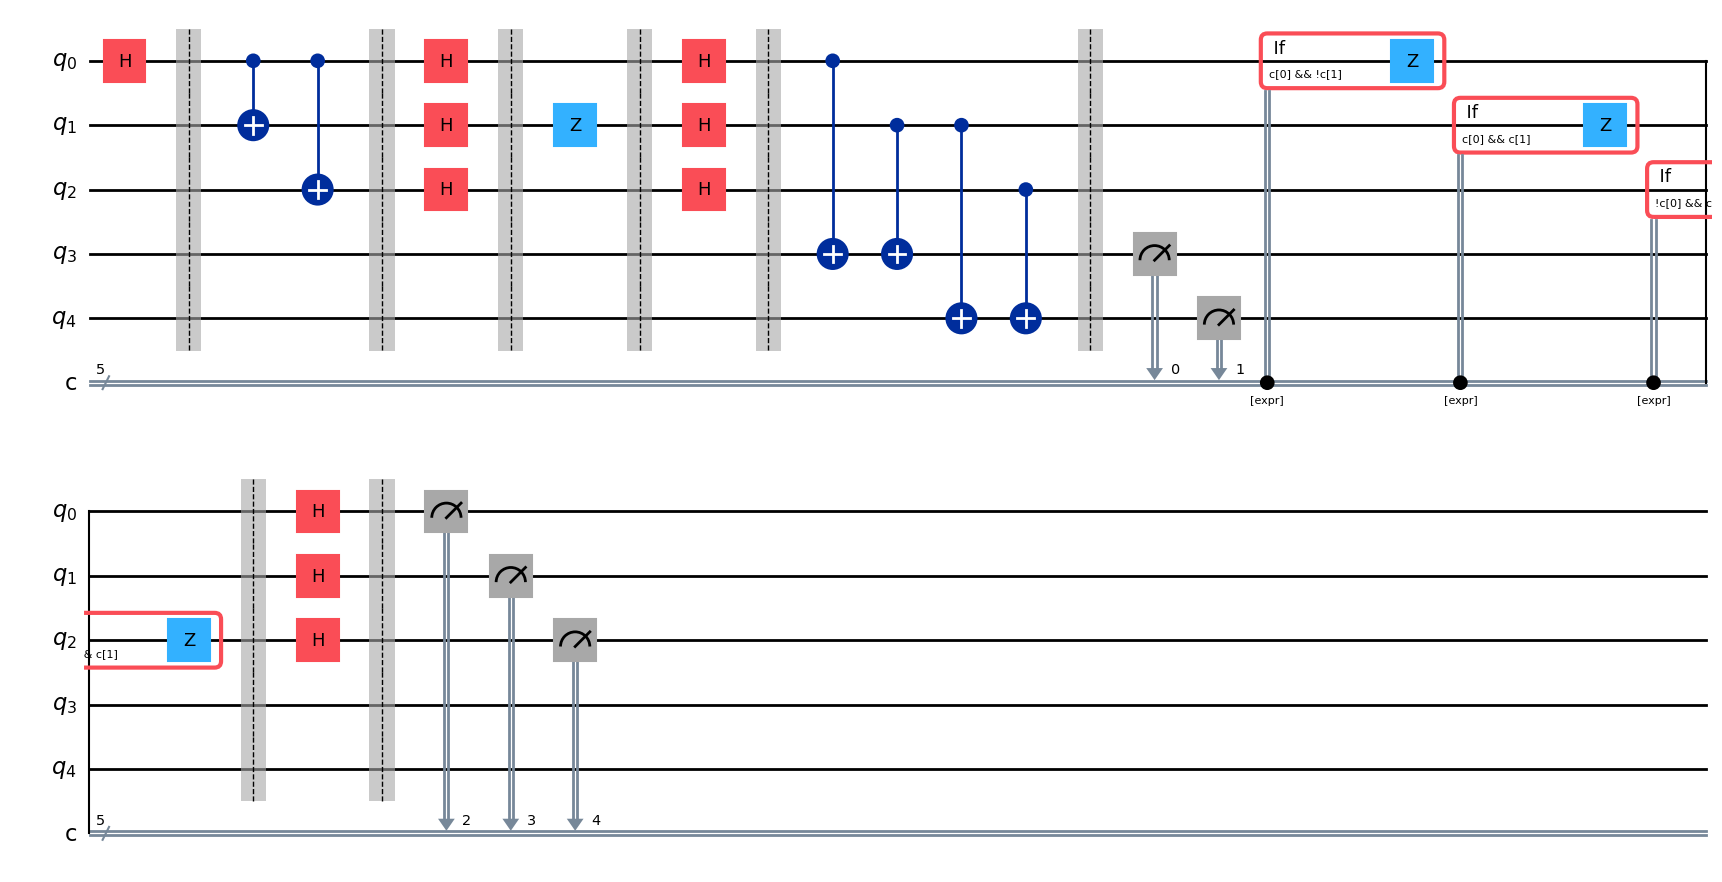

In [4]:
# Three qubit phase-flip error-correcting code

flip = QuantumCircuit(5, 5)

# qubit 0 is the original qubit
# qubits 1 and 2 are used for encoding
# qubits 3 and 4 are used for syndrome
# classical bits 0 and 1 are syndrome results
# classical bits 2, 3, 4 are final measurements

# Prepare original qubit
flip.h(0)

flip.barrier()

# Encode qubit 0 onto qubits 1 and 2
flip.cx(0, 1)
flip.cx(0, 2)

flip.barrier()

# Convert bit-flip code into phase-flip code basis
flip.h(0)
flip.h(1)
flip.h(2)

flip.barrier()

# Add a phase-flip error
# Try flip.z(0), flip.z(1), or flip.z(2)
flip.z(1)

# Try two phase flips:
# flip.z(0)
# flip.z(1)

# Try a bit flip:
# flip.x(1)

flip.barrier()

# Convert phase-flip error into bit-flip error
flip.h(0)
flip.h(1)
flip.h(2)

flip.barrier()

# Syndrome measurements
flip.cx(0, 3)
flip.cx(1, 3)
flip.cx(1, 4)
flip.cx(2, 4)

flip.barrier()

flip.measure([3, 4], [0, 1])

# Conditional correction
# For phase-flip code, correct using Z after identifying which qubit had the phase flip.

with flip.if_test(expr.logic_and(flip.clbits[0], expr.logic_not(flip.clbits[1]))):
    flip.z(0)

with flip.if_test(expr.logic_and(flip.clbits[0], flip.clbits[1])):
    flip.z(1)

with flip.if_test(expr.logic_and(expr.logic_not(flip.clbits[0]), flip.clbits[1])):
    flip.z(2)

flip.barrier()

# Convert back before measuring in computational basis
flip.h(0)
flip.h(1)
flip.h(2)

flip.barrier()

# Final measurement
flip.measure([0, 1, 2], [2, 3, 4])

flip.draw("mpl")

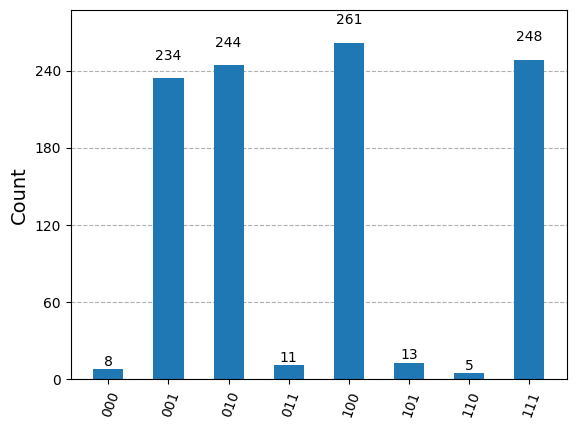

In [5]:
# Simulate and plot results

backend = GenericBackendV2(num_qubits=5, control_flow=True)
compiled = transpile(flip, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
# We only want to see the results for bits 2, 3, 4
mcounts = marginal_counts(counts,indices=[2,3,4])
plot_histogram(mcounts)

In [6]:
# Phase flip error = Z error
# # To correct phase flips, we convert phase errors into bit-flip errors using Hadamard gates.
# Bit flip error = X error